---
## ⚙️ Configuration

In [1]:
# =====================================================================
# 🔧 CONFIGURATION — edit only this cell
# =====================================================================

# --- Mode switches ---
FILTER_MODE   = "all"       # "all" | "excel" | "manual"
ANALYSIS_MODE = "scoring"   # "scoring" | "clustering" | "both"

# --- Time window ---
MONTHS_BACK   = 8           # Analyze last N months only

# --- Manual charger list (used when FILTER_MODE = "manual") ---
SELECTED_CHARGERS = [
    # Finland
    "Hy6NfZ", "YX5xq0", "BkJsud", "nFJBZS", "ZIJhLf", "AZNNJA", "z4gi5Z", "acno33",
    "GcIKxl", "udABVw", "hE5gvw", "Mgx7DR", "ZligFW", "N3Btwu", "sJT41a", "lpuy1j",
    "liZll0", "hJYSAt", "fXnldw", "nqq1M7", "XzC5nW", "jKNdUi", "V2KgdI", "56VYaM",
    "LIjq41", "WJv88t", "rI01JZ", "kXnNip", "Mu3puO", "PdbewO", "gkybxl", "2H1Hul",
    # Sweden (uncomment to include)
    # "LCk4jo", "gwmF5L", "UzOYLO", "GHTN2X", "THLN7m", "JlBtzX", "eZCh8O",
]

# --- Excel filter (used when FILTER_MODE = "excel") ---
EXCEL_FILTER_PATH = "../data_all/Master_file_Outlet_issues.xlsx"

# --- Data paths ---
DATA_DIR  = "../data_all"
CTD_FILE  = "CTD_Logs.csv"
PLE_FILE  = "PLE_Logs.csv"
SESS_FILE = "SeccSessionStop_Logs.csv"

# --- Output ---
TOP_N            = 40           # Number of top outlets to export
OUTPUT_DIR       = "../outputs_unified_10062026"
ROLLING_WINDOW   = 30           # Rolling window for plots (days)
DURATION_UNIT    = "min"        # Label for duration axis

# --- Clustering parameters (used when ANALYSIS_MODE includes clustering) ---
MIN_WEEKS        = 26           # Minimum weeks of data to keep an outlet
OUTLIER_Q        = 0.99         # Weekly 99th-percentile cap
K_RANGE          = list(range(3, 9))  # KMeans k values to try
SLOPE_LAST_N     = 8            # Weeks for slope feature
HIGH_TEMP_THR    = 5.0          # °C threshold for high-temp ratio feature

---
## 1 · Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

print("✅ Imports loaded.")

✅ Imports loaded.


---
## 2 · Load Raw Data

In [3]:
ctd_df  = pd.read_csv(os.path.join(DATA_DIR, CTD_FILE))
ple_df  = pd.read_csv(os.path.join(DATA_DIR, PLE_FILE))
sess_df = pd.read_csv(os.path.join(DATA_DIR, SESS_FILE))

for name, df in [("CTD", ctd_df), ("PLE", ple_df), ("Sessions", sess_df)]:
    print(f"\n=== {name} === shape: {df.shape}")
    print("  Columns:", df.columns.tolist())
    display(df.head(2))


=== CTD === shape: (1181134, 13)
  Columns: ['@timestamp', 'IDOutlet', 'cause', 'cableid', 'nowcur', 'Contacttemp', 'Contacttemp2', 'diff', 'factor', 'EVID', 'Energy', 'duration', '@ptr']


,@timestamp,IDOutlet,cause,cableid,nowcur,Contacttemp,Contacttemp2,diff,factor,EVID,Energy,duration,@ptr
0,2026-01-11 13:31:58.294000+00:00,vp0w5i2,debug,DC2,199,9.0,4.0,5.0,0.04523,EV-T2HPCC-DC,14.4,12.7811,Cm4KKwoVNjg5MTE3MzE0NzAwOm1lc3NhZ2VzEAIiDgimuo...
1,2026-01-11 13:32:12.221000+00:00,h37RLm1,debug,DC1,287,22.8,12.6,10.2,0.07944,EV-T2M4CC-DC,4.7,2.6208,Cm4KKwoVNjg5MTE3MzE0NzAwOm1lc3NhZ2VzEAYiDgimuo...



=== PLE === shape: (1058843, 4)
  Columns: ['IDOutlet', '@timestamp', 'Error', '@ptr']


,IDOutlet,@timestamp,Error,@ptr
0,dqq1Zm1,2026-01-11 13:34:38.973000+00:00,Error,Cm4KKwoVNjg5MTE3MzE0NzAwOm1lc3NhZ2VzEAMiDgimuo...
1,dqq1Zm1,2026-01-11 13:35:31.111000+00:00,Error,Cm4KKwoVNjg5MTE3MzE0NzAwOm1lc3NhZ2VzEAIiDgimuo...



=== Sessions === shape: (5187977, 9)
  Columns: ['IDOutlet', '@timestamp', 'pt1000_1_T', 'pt1000_2_T', 'duration', 'energy', 'diff', 'Energydiff', '@ptr']


,IDOutlet,@timestamp,pt1000_1_T,pt1000_2_T,duration,energy,diff,Energydiff,@ptr
0,vgcKOK2,2026-01-11 13:32:01.421000+00:00,11.4019,11.4019,3221.0,56251.0,0.00,0.00000,Cm4KKwoVNjg5MTE3MzE0NzAwOm1lc3NhZ2VzEAQiDgimuo...
1,UhGCB81,2026-01-11 13:32:03.389000+00:00,11.4000,10.8800,1128.0,15090.0,0.52,0.03446,Cm4KKwoVNjg5MTE3MzE0NzAwOm1lc3NhZ2VzEAIiDgimuo...


---
## 3 · Normalize Charger + Outlet IDs

Split `IDOutlet` → `@logStream` (charger) + `outlet` (last digit, e.g. 1–4).

In [4]:
def split_idoutlet(id_str):
    """Split IDOutlet into (charger_id, outlet_int)."""
    if pd.isna(id_str):
        return (pd.NA, pd.NA)
    s = str(id_str)
    if s[-1].isdigit():
        return (s[:-1], int(s[-1]))
    return (s, pd.NA)


for df in [ctd_df, ple_df, sess_df]:
    splits = df["IDOutlet"].apply(split_idoutlet)
    df["@logStream"] = splits.apply(lambda x: x[0]).astype(str).str.strip()
    df["outlet"]     = splits.apply(lambda x: x[1]).astype("Int64")

# Verify CTD cableid consistency
if "cableid" in ctd_df.columns:
    ctd_df["_cbl"] = ctd_df["cableid"].apply(
        lambda x: int(str(x)[-1]) if pd.notna(x) and str(x)[-1].isdigit() else pd.NA
    ).astype("Int64")
    n_mis = (ctd_df["outlet"] != ctd_df["_cbl"]).sum()
    print("✅ CTD cableid check:", "consistent" if n_mis == 0 else f"{n_mis} mismatches")
    ctd_df.drop(columns=["_cbl"], inplace=True)

print("✅ Charger + outlet columns created.")

✅ CTD cableid check: consistent
✅ Charger + outlet columns created.


---
## 4 · Parse Timestamps & Sort

In [5]:
for df in [ctd_df, ple_df, sess_df]:
    df["@timestamp"] = pd.to_datetime(df["@timestamp"], errors="coerce")
    df.sort_values("@timestamp", inplace=True)
    df["day"] = df["@timestamp"].dt.floor("D")

# Convert session duration seconds → minutes
sess_df["duration"] = pd.to_numeric(sess_df["duration"], errors="coerce")
sess_df["duration_min"] = sess_df["duration"] / 60.0

# Limit to last N months (based on the latest date across all tables)
latest_day = max(
    ctd_df["day"].max(),
    ple_df["day"].max(),
    sess_df["day"].max(),
)
cutoff_day = latest_day - pd.DateOffset(months=int(MONTHS_BACK))

before = (len(ctd_df), len(ple_df), len(sess_df))
ctd_df  = ctd_df[ctd_df["day"] >= cutoff_day].copy()
ple_df  = ple_df[ple_df["day"] >= cutoff_day].copy()
sess_df = sess_df[sess_df["day"] >= cutoff_day].copy()
after = (len(ctd_df), len(ple_df), len(sess_df))

print(f"✅ Timestamps parsed. Keeping last {MONTHS_BACK} months")
print(f"   Date range: {cutoff_day} → {latest_day}")
print(f"   Rows CTD {before[0]:,}→{after[0]:,} | PLE {before[1]:,}→{after[1]:,} | Sess {before[2]:,}→{after[2]:,}")

# Quick sanity check on duration
_d = sess_df["duration_min"].dropna()
if not _d.empty:
    print("✅ Session duration_min (minutes) quantiles:", _d.quantile([0.01, 0.5, 0.99]).to_dict())

✅ Timestamps parsed. Keeping last 8 months
   Date range: 2025-10-10 00:00:00+00:00 → 2026-06-10 00:00:00+00:00
   Rows CTD 1,181,134→1,180,072 | PLE 1,058,843→1,057,715 | Sess 5,187,977→5,182,868
✅ Session duration_min (minutes) quantiles: {0.01: 1.9666666666666666, 0.5: 29.466666666666665, 0.99: 196.75}


---
## 5 · Filter Chargers / Outlets

Controlled by `FILTER_MODE` in the configuration cell.

In [6]:
if FILTER_MODE == "manual":
    print(f"🔘 Manual filter: {len(SELECTED_CHARGERS)} chargers selected.")
    ctd_filt  = ctd_df[ctd_df["@logStream"].isin(SELECTED_CHARGERS)].copy()
    ple_filt  = ple_df[ple_df["@logStream"].isin(SELECTED_CHARGERS)].copy()
    sess_filt = sess_df[sess_df["@logStream"].isin(SELECTED_CHARGERS)].copy()

elif FILTER_MODE == "excel":
    _fdf = pd.read_excel(EXCEL_FILTER_PATH)
    _fdf = _fdf.rename(columns={"ID": "@logStream", "Outlet": "outlet"})
    _fdf["@logStream"] = _fdf["@logStream"].astype(str).str.strip()
    _fdf["outlet"]     = _fdf["outlet"].astype("Int64")
    _pairs = set(zip(_fdf["@logStream"], _fdf["outlet"]))
    print(f"🔘 Excel filter: {len(_pairs)} charger–outlet pairs.")

    def _pair_filter(df):
        return df[df[["@logStream","outlet"]].apply(tuple, axis=1).isin(_pairs)].copy()

    ctd_filt  = _pair_filter(ctd_df)
    ple_filt  = _pair_filter(ple_df)
    sess_filt = _pair_filter(sess_df)

else:  # "all"
    print("🔘 No filter: using ALL chargers/outlets.")
    ctd_filt  = ctd_df.copy()
    ple_filt  = ple_df.copy()
    sess_filt = sess_df.copy()

for name, before, after in [("CTD", len(ctd_df), len(ctd_filt)),
                             ("PLE", len(ple_df), len(ple_filt)),
                             ("Sessions", len(sess_df), len(sess_filt))]:
    print(f"   {name}: {before:,} → {after:,} rows")

🔘 No filter: using ALL chargers/outlets.
   CTD: 1,180,072 → 1,180,072 rows
   PLE: 1,057,715 → 1,057,715 rows
   Sessions: 5,182,868 → 5,182,868 rows


---
## 6 · Daily Aggregation

In [7]:
ctd_summary = ctd_filt.groupby(["@logStream", "outlet", "day"]).agg(
    CTD_count        = ("@timestamp", "count"),
    CTD_diff_mean    = ("diff", "mean"),
    CTD_factor_mean  = ("factor", "mean"),
    CTD_current_mean = ("nowcur", "mean"),
).reset_index()

ple_summary = ple_filt.groupby(["@logStream", "outlet", "day"]).agg(
    PLE_count = ("@timestamp", "count"),
).reset_index()

sess_summary = sess_filt.groupby(["@logStream", "outlet", "day"]).agg(
    Sess_count          = ("@timestamp", "count"),
    Sess_energy_mean    = ("energy", "mean"),
    Sess_temp_diff_mean = ("diff", "mean"),
    Sess_temp_diff_max  = ("diff", "max"),
    Sess_duration_mean  = ("duration_min", "mean"),
    Sess_duration_total = ("duration_min", "sum"),
).reset_index()

print(f"✅ Daily aggregation: CTD {ctd_summary.shape}, PLE {ple_summary.shape}, Sess {sess_summary.shape}")

✅ Daily aggregation: CTD (250926, 7), PLE (21004, 4), Sess (667337, 9)


---
## 7 · Merge into Master Timeline

In [8]:
master = (
    ctd_summary
    .merge(sess_summary, on=["@logStream", "outlet", "day"], how="outer")
    .merge(ple_summary,  on=["@logStream", "outlet", "day"], how="outer")
)
master["day"] = pd.to_datetime(master["day"], errors="coerce")
master.sort_values(["@logStream", "outlet", "day"], inplace=True)

# Zero-fill counts; mask means where count = 0
count_cols = [c for c in master.columns if c.endswith("_count")]
mean_cols  = [c for c in master.columns if c.endswith("_mean") or c.endswith("_max") or c.endswith("_total")]
for c in count_cols + mean_cols:
    master[c] = pd.to_numeric(master[c], errors="coerce")
master[count_cols] = master[count_cols].fillna(0)

# Mask CTD means where no CTD events
for c in ["CTD_diff_mean", "CTD_factor_mean", "CTD_current_mean"]:
    if c in master.columns:
        master.loc[master["CTD_count"] == 0, c] = np.nan

master["outlet"] = pd.to_numeric(master["outlet"], errors="coerce").astype("Int64")

n_chargers = master["@logStream"].nunique()
n_outlets  = master[["@logStream", "outlet"]].drop_duplicates().shape[0]
print(f"✅ Master timeline: {master.shape[0]:,} rows | {n_chargers} chargers | {n_outlets} outlets")

✅ Master timeline: 693,788 rows | 3958 chargers | 8741 outlets


---
## 8 · Feature Engineering

In [9]:
def add_features(df):
    df = df.copy()
    df["Energy_per_session"] = np.where(
        df["Sess_count"] > 0, df["Sess_energy_mean"] / df["Sess_count"], np.nan)
    df["Energy_per_duration"] = np.where(
        df["Sess_duration_mean"] > 0, df["Sess_energy_mean"] / df["Sess_duration_mean"], np.nan)
    df["CTD_per_session"] = np.where(
        df["Sess_count"] > 0, df["CTD_count"] / df["Sess_count"], np.nan)
    df["PLE_per_session"] = np.where(
        df["Sess_count"] > 0, df["PLE_count"] / df["Sess_count"], np.nan)
    return df

outlet_timeline = add_features(master)
print("✅ Features added: Energy_per_session, Energy_per_duration, CTD_per_session, PLE_per_session")

✅ Features added: Energy_per_session, Energy_per_duration, CTD_per_session, PLE_per_session


---
## 9A · Rule-Based Scoring (v2 — Recent-Rise Focus)

| Rule | Points | Notes |
|:-----|-------:|:------|
| **Recent rise**: median(last 60d) − median(prior 60d) > 3°C | +5 | Core signal |
| Median temp diff > 5°C (last 60 days) | +3 | Absolute level |
| Median temp diff > 10°C (last 60 days) | +2 | Severe level |
| Recent slope positive (last 60d) | +2 | Still climbing |
| ≥100% rise in last 30 days | +2 | Fast acceleration |
| **Stable-high penalty**: if prior 60d median already >5°C and rise <1°C | −3 | Avoid "always high" |
| >500 total sessions (data confidence) | +1 | Stability bonus |

> Skipped if `ANALYSIS_MODE = "clustering"`.

In [10]:
def score_outlets_v2(timeline, min_sessions=300, min_days_with_data=60):
    """
    Scoring focused on RECENT sharp rises (last 60 days vs prior 60 days).
    Penalizes outlets that were always high but stable.
    
    Filters:
      - min_sessions: minimum total sessions over the period (default 300)
      - min_days_with_data: minimum days with at least 1 session (default 60)
    """
    results = []
    for (charger, outlet), grp in timeline.groupby(["@logStream", "outlet"]):
        total_sess = grp["Sess_count"].sum()
        days_with_data = (grp["Sess_count"] > 0).sum()
        
        # Skip outlets with insufficient data
        if total_sess < min_sessions:
            continue
        if days_with_data < min_days_with_data:
            continue

        temp = grp["Sess_temp_diff_mean"].fillna(0).values
        n = len(temp)

        # Split into recent (last 60d) vs prior (60-120d ago)
        recent_60 = temp[-60:] if n >= 60 else temp
        prior_60  = temp[-120:-60] if n >= 120 else temp[:max(1, n-60)]

        med_recent = np.median(recent_60)
        med_prior  = np.median(prior_60) if len(prior_60) > 0 else 0
        rise = med_recent - med_prior

        # Slope of recent 60 days
        if len(recent_60) >= 10:
            x = np.arange(len(recent_60))
            slope_recent = np.polyfit(x, recent_60, 1)[0]
        else:
            slope_recent = 0

        # Fast rise in last 30 days
        last_30 = temp[-30:] if n >= 30 else temp
        first_of_30 = last_30[0] if len(last_30) > 0 else 1
        pct_rise_30 = (last_30[-1] - first_of_30) / max(first_of_30, 0.5) if len(last_30) > 1 else 0

        contrib, score = {}, 0

        # +5: Recent rise > 3°C
        if rise > 3:
            contrib["Recent rise >3°C"] = 5
            score += 5

        # +3: Median > 5°C (recent)
        if med_recent > 5:
            contrib["Median >5°C (recent)"] = 3
            score += 3

        # +2: Median > 10°C (recent)
        if med_recent > 10:
            contrib["Median >10°C"] = 2
            score += 2

        # +2: Recent slope positive
        if slope_recent > 0.02:
            contrib["Slope ↑ (60d)"] = 2
            score += 2

        # +2: ≥100% rise in 30 days
        if pct_rise_30 >= 1.0:
            contrib["100% rise 30d"] = 2
            score += 2

        # −3: Stable-high penalty (was already high, no recent change)
        if med_prior > 5 and rise < 1:
            contrib["Stable-high penalty"] = -3
            score -= 3

        # +1: High data confidence (many sessions)
        if total_sess > 1000:
            contrib["High data volume"] = 1
            score += 1

        results.append({
            "@logStream": charger,
            "outlet": outlet,
            "Score": score,
            "total_sessions": int(total_sess),
            "days_with_data": int(days_with_data),
            "med_recent": round(med_recent, 2),
            "med_prior": round(med_prior, 2),
            "rise": round(rise, 2),
            "Contributions": contrib,
        })

    ranking = (pd.DataFrame(results)
               .sort_values("Score", ascending=False)
               .reset_index(drop=True))
    ranking["Rank"] = ranking.index + 1
    return ranking


if ANALYSIS_MODE in ("scoring", "both"):
    scoring_ranking = score_outlets_v2(outlet_timeline, min_sessions=300, min_days_with_data=60)
    print(f"✅ Rule-based scoring (v2): {len(scoring_ranking)} outlets scored (min 300 sessions, 60 days).")
    display(scoring_ranking.head(15))
else:
    scoring_ranking = None
    print("⏭️ Scoring skipped (ANALYSIS_MODE = clustering).")

✅ Rule-based scoring (v2): 3578 outlets scored (min 300 sessions, 60 days).


,@logStream,outlet,Score,total_sessions,days_with_data,med_recent,med_prior,rise,Contributions,Rank
0,XDroR9,2,13,8587,150,9.97,3.89,6.08,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",1
1,evBHNP,2,11,3511,128,10.93,4.41,6.52,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",2
2,0BTBMJ,2,11,1363,143,7.62,3.83,3.79,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",3
3,Te2BNh,1,11,2555,148,9.59,5.73,3.86,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",4
4,28JUhB,1,11,5245,146,15.82,7.63,8.19,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",5
5,aB6POl,3,11,2080,134,6.57,3.42,3.15,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",6
6,j0VMyG,3,11,1460,147,5.44,1.60,3.84,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",7
7,053Wej,2,11,1148,148,5.84,2.27,3.57,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",8
8,Ubbd7a,1,10,823,72,9.99,3.59,6.40,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",9
9,iwBG9A,1,9,2098,144,5.69,2.02,3.67,"{'Recent rise >3°C': 5, 'Median >5°C (recent)'...",10


---
## 9B · Weekly Clustering + ML Risk Score

Pipeline:
1. Weekly mean temp-diff per outlet
2. Outlier capping (99th percentile)
3. Align to common weekly timeline + interpolate
4. Z-score normalization per outlet
5. Enriched features (mean, max, high-temp ratio, slope)
6. KMeans model selection (silhouette)
7. Identify failure-like cluster (highest rising trend)
8. Risk score = 0.6 × proximity + 0.2 × slope24 + 0.2 × slope12

> Skipped if `ANALYSIS_MODE = "scoring"`.

In [11]:
if ANALYSIS_MODE in ("clustering", "both"):
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score, davies_bouldin_score
    from numpy.linalg import norm

    # --- Prepare session-level data ---
    # @logStream = charger ID (without outlet digit), outlet = digit
    _s = sess_filt[["@logStream", "outlet", "day", "diff"]].copy()
    _s.columns = ["charger_id", "outlet", "day", "Sess_temp_diff_mean"]
    _s["Sess_temp_diff_mean"] = pd.to_numeric(_s["Sess_temp_diff_mean"], errors="coerce")
    _s = _s.dropna(subset=["Sess_temp_diff_mean"])
    _s["outlet"] = _s["outlet"].astype(str)
    _s["week"]   = _s["day"].dt.to_period("W").dt.start_time

    # 1) Weekly aggregation
    df_weekly = (
        _s.groupby(["charger_id", "outlet", "week"], as_index=False)["Sess_temp_diff_mean"]
          .mean()
          .sort_values(["charger_id", "outlet", "week"])
    )

    # 2) Filter outlets with < MIN_WEEKS
    _counts = df_weekly.groupby(["charger_id", "outlet"])["week"].count().reset_index(name="n")
    _valid  = _counts[_counts["n"] >= MIN_WEEKS][["charger_id", "outlet"]]
    df_weekly = df_weekly.merge(_valid, on=["charger_id", "outlet"], how="inner")
    print(f"✅ {df_weekly[['charger_id','outlet']].drop_duplicates().shape[0]} outlets with ≥{MIN_WEEKS} weeks")

    # 3) Outlier capping (per outlet) — using transform to avoid pandas 3.0 apply issues
    _caps = df_weekly.groupby(["charger_id", "outlet"])["Sess_temp_diff_mean"].transform(
        lambda x: x.quantile(OUTLIER_Q)
    )
    df_weekly["Sess_temp_diff_mean"] = np.clip(df_weekly["Sess_temp_diff_mean"], None, _caps)

    # 4) Align to common weekly timeline + interpolate
    full_weeks = pd.date_range(df_weekly["week"].min(), df_weekly["week"].max(), freq="W-MON")
    aligned = []
    for (cid, out), g in df_weekly.groupby(["charger_id", "outlet"]):
        g = g.set_index("week").reindex(full_weeks)
        g["Sess_temp_diff_mean"] = g["Sess_temp_diff_mean"].interpolate(limit_direction="both")
        g["charger_id"] = cid; g["outlet"] = out
        aligned.append(g.reset_index().rename(columns={"index": "week"}))
    df_aligned = pd.concat(aligned, ignore_index=True)

    # 5) Z-score per outlet — using transform instead of apply
    _mu = df_aligned.groupby(["charger_id", "outlet"])["Sess_temp_diff_mean"].transform("mean")
    _sd = df_aligned.groupby(["charger_id", "outlet"])["Sess_temp_diff_mean"].transform("std")
    df_aligned["z"] = np.where(_sd > 0, (df_aligned["Sess_temp_diff_mean"] - _mu) / _sd, 0.0)

    # Weekly feature matrix
    mat = (
        df_aligned.pivot_table(index=["charger_id", "outlet"], columns="week", values="z")
        .sort_index(axis=1).fillna(0.0)
    )
    n_weeks_mat = mat.shape[1]
    print(f"✅ Weekly z-matrix: {mat.shape}")

    # 6) Enriched summary features
    def _slope(vals, n=8):
        vals = np.asarray(vals, dtype=float)
        if len(vals) < n: return 0.0
        sub = vals[-n:]; x = np.arange(len(sub))
        d = np.sum((x - x.mean())**2)
        return np.sum((x - x.mean()) * (sub - sub.mean())) / d if d else 0.0

    _summ = df_aligned.groupby(["charger_id", "outlet"]).agg(
        mean_temp  = ("Sess_temp_diff_mean", "mean"),
        max_temp   = ("Sess_temp_diff_mean", "max"),
        weeks_data = ("Sess_temp_diff_mean", "count"),
    ).reset_index()

    _hr = (df_aligned.assign(high=(df_aligned["Sess_temp_diff_mean"] > HIGH_TEMP_THR).astype(int))
           .groupby(["charger_id", "outlet"])["high"].mean()
           .reset_index(name="high_weeks_ratio"))
    _summ = _summ.merge(_hr, on=["charger_id", "outlet"], how="left")

    _slopes = []
    for (cid, out), sub in df_aligned.sort_values("week").groupby(["charger_id", "outlet"]):
        _slopes.append({"charger_id": cid, "outlet": out,
                        "slope_8w": _slope(sub["Sess_temp_diff_mean"].values, SLOPE_LAST_N)})
    _summ = _summ.merge(pd.DataFrame(_slopes), on=["charger_id", "outlet"], how="left")

    extra = _summ.set_index(["charger_id", "outlet"]).reindex(mat.index).fillna(0).to_numpy(float)
    X = np.hstack([mat.to_numpy(float), extra])
    print(f"✅ Enriched feature matrix: {X.shape}")

    # 7) KMeans model selection
    best_sil, best_model, best_k = -1, None, None
    model_results = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        model_results.append({"k": k, "silhouette": sil, "davies_bouldin": dbi})
        print(f"  k={k}: silhouette={sil:.4f}, DB={dbi:.4f}")
        if sil > best_sil:
            best_sil, best_model, best_k = sil, km, k

    print(f"\n✅ Best K = {best_k} (silhouette = {best_sil:.4f})")
    labels = best_model.labels_
    centers = best_model.cluster_centers_

    # 8) Identify failure-like cluster
    cluster_slopes = []
    for c in range(best_k):
        v = centers[c, :n_weeks_mat]
        cluster_slopes.append({"cluster": c, "slope": _slope(v, len(v))})
    _cs = pd.DataFrame(cluster_slopes).sort_values("slope", ascending=False)
    failure_cluster = int(_cs.iloc[0]["cluster"])
    print(f"⚡ Failure-like cluster: {failure_cluster}")

    # 9) Risk score
    fail_cent = centers[failure_cluster]
    dists = norm(X - fail_cent[None, :], axis=1)

    s12 = np.array([_slope(X[i], 12) for i in range(X.shape[0])])
    s24 = np.array([_slope(X[i], 24) for i in range(X.shape[0])])

    def _minmax(x):
        a, b = np.nanmin(x), np.nanmax(x)
        return (x - a) / (b - a) if b > a else np.zeros_like(x)

    risk = 0.6 * (1 - _minmax(dists)) + 0.2 * _minmax(s24) + 0.2 * _minmax(s12)
    risk_score = (100 * risk).round(1)

    cluster_df = mat.reset_index().copy()
    cluster_df["cluster"]    = labels
    cluster_df["risk_0_100"] = risk_score

    clustering_ranking = (
        cluster_df[["charger_id", "outlet", "cluster", "risk_0_100"]]
        .sort_values("risk_0_100", ascending=False)
        .reset_index(drop=True)
    )
    clustering_ranking["Rank"] = clustering_ranking.index + 1

    # @logStream = charger_id (matches outlet_timeline["@logStream"])
    clustering_ranking["@logStream"] = clustering_ranking["charger_id"]
    clustering_ranking["outlet"]     = clustering_ranking["outlet"].astype("Int64")

    print(f"✅ Clustering risk scored {len(clustering_ranking)} outlets.")
    display(clustering_ranking.head(10))

    # Store cluster IQR data for later plotting
    _cluster_plot_data = (centers, labels, mat.to_numpy(float), n_weeks_mat, best_k)
else:
    clustering_ranking = None
    _cluster_plot_data = None
    print("⏭️ Clustering skipped (ANALYSIS_MODE = scoring).")

⏭️ Clustering skipped (ANALYSIS_MODE = scoring).


---
## 10 · Plotting Helpers

In [12]:
def _cap_q(series, q=0.98):
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().empty: return s
    return np.minimum(s, s.quantile(q))


def _trend(ax, x, y, window=21, color="C0", label=""):
    ax.plot(x, y, marker="o", ls="-", color=color, alpha=0.4, ms=3, label=label)
    roll = pd.Series(y, index=pd.to_datetime(x)).rolling(window, min_periods=1).mean()
    ax.plot(x, roll.values, "--", lw=2, color="black", label=f"Trend ({window}d)")


def plot_outlet_5panel(df, charger, outlet, ranking_df=None,
                        window=30, dur_label="min"):
    """5-panel daily trend: energy, temp diff, event counts, ratios, duration."""
    df = df.sort_values("day").copy()
    df["day"] = pd.to_datetime(df["day"], errors="coerce")

    for col, q in {"Energy_per_session": .90, "Energy_per_duration": .90,
                    "Sess_temp_diff_mean": .90, "Sess_duration_mean": .90,
                    "CTD_count": .99, "PLE_count": .99,
                    "CTD_per_session": .90, "PLE_per_session": .90}.items():
        if col in df: df[col] = _cap_q(df[col], q)

    title = f"{charger} – Outlet {outlet}"
    rank_val = None
    if ranking_df is not None:
        row = ranking_df[(ranking_df["@logStream"] == charger) &
                         (ranking_df["outlet"].astype(str) == str(outlet))]
        if not row.empty:
            sc = row.iloc[0].get("Score", row.iloc[0].get("risk_0_100", ""))
            rk = row.iloc[0]["Rank"]
            title += f" | Score: {sc} | Rank: {rk}"
            rank_val = int(rk)

    fig, axs = plt.subplots(5, 1, figsize=(18, 20), sharex=True)
    fig.suptitle(title, fontsize=14)

    panels = [
        (0, "Energy Usage", "Wh",
         [("Energy_per_session", "green", "Wh/Session"),
          ("Energy_per_duration", "darkgreen", f"Wh/{dur_label}")] ),
        (1, "Session Temp Diff (°C)", "°C",
         [("Sess_temp_diff_mean", "orange", "Temp Diff")] ),
        (2, "Event Counts", "count",
         [("CTD_count", "brown", "CTD"), ("PLE_count", "blue", "PLE")] ),
        (3, "Ratios (per Session)", "ratio",
         [("CTD_per_session", "red", "CTD/Session"),
          ("PLE_per_session", "blue", "PLE/Session")] ),
        (4, f"Session Duration ({dur_label})", dur_label,
         [("Sess_duration_mean", "purple", "Duration")] ),
    ]
    for idx, ptitle, ylabel, series_list in panels:
        for col, color, label in series_list:
            if col in df:
                _trend(axs[idx], df["day"], df[col].to_numpy(float), window, color, label)
        axs[idx].set_title(ptitle); axs[idx].set_ylabel(ylabel)
        axs[idx].legend(loc="upper left"); axs[idx].grid(alpha=0.2)
    axs[3].axhline(1, color="gray", ls="--", alpha=0.6)
    axs[-1].xaxis.set_major_locator(mdates.MonthLocator())
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    return fig, rank_val


def plot_daily_3panel(daily_df, charger_id, outlet, rank, risk,
                       window=30, dur_label="min"):
    """3-panel daily plot: max ΔT + 5°C line, energy, duration."""
    sub = daily_df.copy().sort_values("day")
    sub["temp_cap"]   = _cap_q(sub["Sess_temp_diff_max"], 0.98)
    sub["energy_cap"] = _cap_q(sub["Sess_energy_mean"], 0.98)
    sub["dur_cap"]    = _cap_q(sub["Sess_duration_mean"], 0.98)
    sub["temp_roll"]  = sub["temp_cap"].rolling(window, min_periods=5).mean()

    fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f"Rank {rank} | {charger_id} – Outlet {outlet} | Risk={risk}", fontsize=14)

    axs[0].plot(sub["day"], sub["temp_cap"], "o-", alpha=0.4, label="Daily max ΔT")
    axs[0].plot(sub["day"], sub["temp_roll"], "--r", lw=2, label=f"{window}d rolling")
    axs[0].axhline(5.0, color="gray", ls="--", lw=1, label="5°C threshold")
    axs[0].set_ylabel("Max Temp Diff (°C)"); axs[0].legend(); axs[0].grid(alpha=0.2)

    axs[1].plot(sub["day"], sub["energy_cap"], "o-", alpha=0.4)
    axs[1].set_ylabel("Energy mean (Wh)"); axs[1].set_title("Daily Energy"); axs[1].grid(alpha=0.2)

    axs[2].plot(sub["day"], sub["dur_cap"], "o-", alpha=0.4, color="purple")
    axs[2].set_ylabel(f"Duration ({dur_label})"); axs[2].set_xlabel("Date"); axs[2].grid(alpha=0.2)

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    return fig


def plot_cluster_iqr(centers, labels, X_week, n_weeks, best_k, save_dir):
    """Cluster mean ± IQR curves."""
    os.makedirs(save_dir, exist_ok=True)
    for c in range(best_k):
        idx = np.where(np.array(labels) == c)[0]
        if len(idx) == 0: continue
        series = X_week[idx, :]
        q25 = np.nanquantile(series, 0.25, axis=0)
        q75 = np.nanquantile(series, 0.75, axis=0)
        mean = np.nanmean(series, axis=0)
        weeks = np.arange(mean.size)

        plt.figure(figsize=(7, 4))
        plt.plot(weeks, mean, lw=2, label=f"Cluster {c}")
        plt.fill_between(weeks, q25, q75, alpha=0.25, label="IQR")
        plt.axhline(0, color="gray", lw=1, ls="--")
        plt.title(f"Cluster {c} – Mean ± IQR (n={len(idx)})")
        plt.xlabel("Week"); plt.ylabel("Z-scored Temp Diff")
        plt.legend(); plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"cluster_{c}_iqr.png"), dpi=150)
        plt.close()

print("✅ Plot helpers defined.")

✅ Plot helpers defined.


---
## 11 · Export Results & Plots

In [13]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ensure optional clustering globals exist (when running scoring-only)
clustering_ranking = globals().get("clustering_ranking", None)
_cluster_plot_data = globals().get("_cluster_plot_data", None)

# --- Choose which ranking to plot ---
if ANALYSIS_MODE == "scoring":
    active_ranking = scoring_ranking
elif ANALYSIS_MODE == "clustering":
    active_ranking = clustering_ranking
else:  # "both" → use scoring as primary
    active_ranking = scoring_ranking

# --- Load charger metadata ---
metadata_path = os.path.join(DATA_DIR, "Charging_station_id_Country_customer.csv")
if os.path.exists(metadata_path):
    # Skip first 2 rows (header info), use row 3 as column names
    try:
        meta_df = pd.read_csv(metadata_path, skiprows=2, encoding='utf-8')
    except UnicodeDecodeError:
        # Try with latin-1 encoding if utf-8 fails
        meta_df = pd.read_csv(metadata_path, skiprows=2, encoding='latin-1')
    
    meta_df.columns = ['charging_station_id', 'country', 'cust_name']
    # Clean up null values
    meta_df = meta_df.fillna('')
    print(f"📋 Loaded metadata: {len(meta_df)} chargers")
else:
    meta_df = pd.DataFrame(columns=['charging_station_id', 'country', 'cust_name'])
    print("⚠️ No metadata file found - proceeding without country/customer info")

# --- Enrich ranking with metadata ---
top_enriched = active_ranking.head(TOP_N).copy()
# Match @logStream (charger ID) with charging_station_id
top_enriched = top_enriched.merge(
    meta_df[['charging_station_id', 'country', 'cust_name']], 
    left_on='@logStream', 
    right_on='charging_station_id', 
    how='left'
)
# Add feedback columns for field teams
top_enriched['Region_Feedback'] = ''     # e.g. "Confirmed" / "False Alarm" / "Replaced" / "Monitoring"
top_enriched['Cable_Photo_Link'] = ''    # URL to photo evidence
top_enriched['Notes'] = ''               # Free text for region comments

# Reorder: Country, Customer, then data columns, then feedback columns at the end
data_cols = [c for c in top_enriched.columns 
             if c not in ['country', 'cust_name', 'charging_station_id',
                          'Region_Feedback', 'Cable_Photo_Link', 'Notes']]
cols = ['country', 'cust_name'] + data_cols + ['Region_Feedback', 'Cable_Photo_Link', 'Notes']
top_enriched = top_enriched[cols]

# --- Save ranking table with date stamp ---
from datetime import datetime
date_str = datetime.now().strftime("%Y-%m-%d")  # e.g., "2026-04-17"
table_fname = f"Top{TOP_N}_ranking_{date_str}.xlsx"
table_path = os.path.join(OUTPUT_DIR, table_fname)
top_enriched.to_excel(table_path, index=False)
print(f"📄 Ranking saved → {table_path}")
print(f"   Columns: Country, Customer, scoring data, Region_Feedback, Cable_Photo_Link, Notes")
print(f"   Total outlets: {len(top_enriched)}")

# --- 5-panel scoring plots ---
if ANALYSIS_MODE in ("scoring", "both") and scoring_ranking is not None:
    plot_dir = os.path.join(OUTPUT_DIR, "scoring_plots")
    os.makedirs(plot_dir, exist_ok=True)
    top = scoring_ranking.head(TOP_N)
    pairs = set(zip(top["@logStream"], top["outlet"].astype(str)))

    for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
        if (charger, str(outlet)) not in pairs or df.empty:
            continue
        fig, rk = plot_outlet_5panel(df, charger, outlet, scoring_ranking,
                                     ROLLING_WINDOW, DURATION_UNIT)
        fname = f"Rank{rk}_{charger}_Outlet{outlet}.png" if rk else f"{charger}_Outlet{outlet}.png"
        fig.savefig(os.path.join(plot_dir, fname), dpi=150)
        plt.close(fig)
    print(f"📊 Scoring plots saved → {plot_dir}/")

# --- 3-panel clustering plots ---
if ANALYSIS_MODE in ("clustering", "both") and clustering_ranking is not None:
    plot_dir_c = os.path.join(OUTPUT_DIR, "clustering_plots")
    os.makedirs(plot_dir_c, exist_ok=True)

    top_c = clustering_ranking.head(TOP_N)

    for _, row in top_c.iterrows():
        charger = row["@logStream"]
        out_val = row["outlet"]
        # Filter outlet_timeline by charger + outlet
        sub = outlet_timeline[
            (outlet_timeline["@logStream"] == charger) &
            (outlet_timeline["outlet"] == out_val)
        ].copy()
        if sub.empty:
            print(f"⚠️ No daily data for {charger} outlet {out_val}")
            continue
        fig = plot_daily_3panel(sub, charger, out_val,
                                row["Rank"], row["risk_0_100"],
                                ROLLING_WINDOW, DURATION_UNIT)
        fname = f"Rank_{int(row['Rank']):02d}_{charger}_Outlet{out_val}.png"
        fig.savefig(os.path.join(plot_dir_c, fname), dpi=150)
        plt.close(fig)
    print(f"📊 Clustering plots saved → {plot_dir_c}/")

    # Cluster IQR plots
    if _cluster_plot_data is not None:
        _cen, _lab, _Xw, _nw, _bk = _cluster_plot_data
        iqr_dir = os.path.join(OUTPUT_DIR, "cluster_iqr_plots")
        plot_cluster_iqr(_cen[:, :_nw], _lab, _Xw, _nw, _bk, iqr_dir)
        print(f"📊 Cluster IQR plots saved → {iqr_dir}/")

    # Clustering CSV exports
    clustering_ranking.to_csv(os.path.join(OUTPUT_DIR, "clusters_with_risk.csv"), index=False)
    top_c.to_csv(os.path.join(OUTPUT_DIR, f"top{TOP_N}_risky_outlets_ML.csv"), index=False)
    print(f"📄 Clustering CSVs saved.")

print(f"\n✅ All exports complete → {OUTPUT_DIR}/")

📋 Loaded metadata: 4123 chargers
📄 Ranking saved → ../outputs_unified_10062026\Top40_ranking_2026-07-28.xlsx
   Columns: Country, Customer, scoring data, Region_Feedback, Cable_Photo_Link, Notes
   Total outlets: 40
📊 Scoring plots saved → ../outputs_unified_10062026\scoring_plots/

✅ All exports complete → ../outputs_unified_10062026/


---
## 13 · Quick View — Inspect a Single Outlet

Change `INSPECT_CHARGER` and `INSPECT_OUTLET` below, then run the cell to see the plot inline.

📊 0ArNKp – Outlet 1: 151 days of data


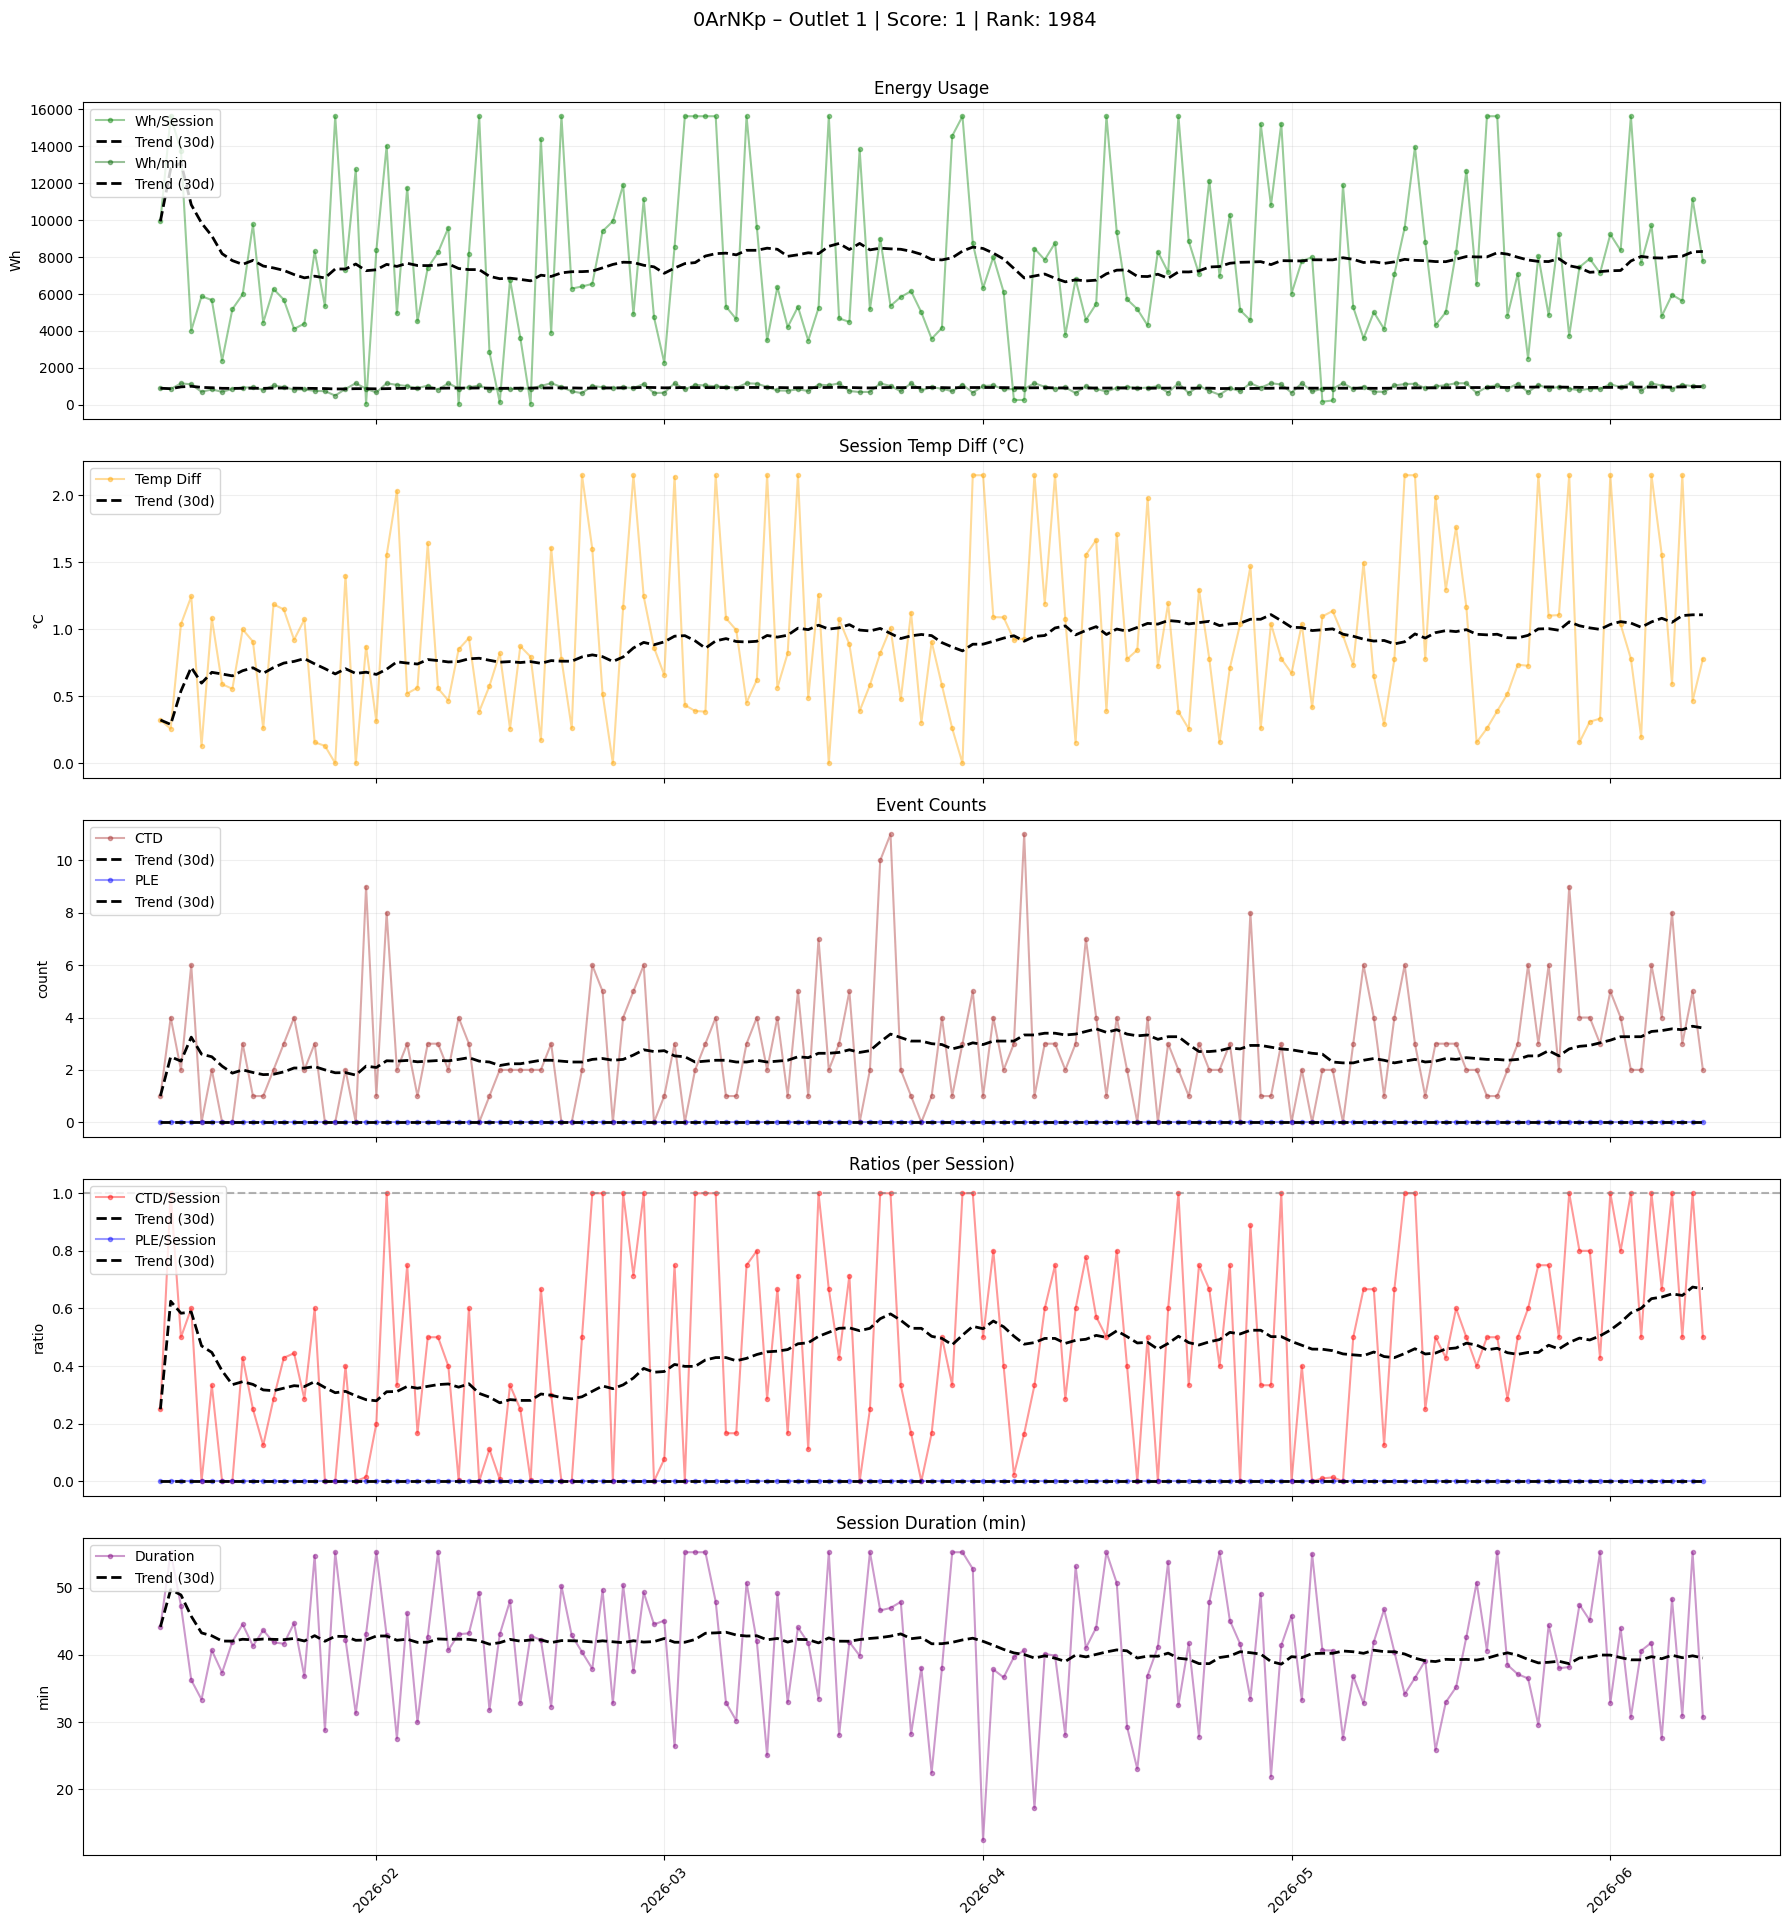

In [14]:
# =====================================================================
# 🔍 QUICK VIEW — change these two values and run this cell
# =====================================================================
INSPECT_CHARGER = "0ArNKp"   # e.g. "Hy6NfZ"  — set to None to auto-pick top-1
INSPECT_OUTLET  = 1          # e.g. 1          — set to None to auto-pick top-1

# Ranking to annotate plots (works even if you didn't run the export cell)
active_ranking = globals().get("active_ranking", None)
if active_ranking is None:
    active_ranking = scoring_ranking if "scoring_ranking" in globals() and scoring_ranking is not None else None

# Auto-pick from ranking if not specified
if INSPECT_CHARGER is None or INSPECT_OUTLET is None:
    if active_ranking is None or active_ranking.empty:
        raise ValueError("No ranking available to auto-pick; run scoring (Cell 20) first.")
    _top1 = active_ranking.iloc[0]
    INSPECT_CHARGER = INSPECT_CHARGER or _top1["@logStream"]
    INSPECT_OUTLET  = INSPECT_OUTLET  or _top1["outlet"]
    print(f"🔍 Auto-selected top-1: {INSPECT_CHARGER} outlet {INSPECT_OUTLET}")

# Filter data
_view = outlet_timeline[
    (outlet_timeline["@logStream"] == INSPECT_CHARGER) &
    (outlet_timeline["outlet"] == int(INSPECT_OUTLET))
].copy()

if _view.empty:
    print(f"⚠️ No data found for {INSPECT_CHARGER} outlet {INSPECT_OUTLET}.")
    print(f"   Available chargers (first 20): {outlet_timeline['@logStream'].unique()[:20].tolist()}")
else:
    print(f"📊 {INSPECT_CHARGER} – Outlet {INSPECT_OUTLET}: {len(_view)} days of data")
    fig, rk = plot_outlet_5panel(
        _view,
        INSPECT_CHARGER,
        INSPECT_OUTLET,
        active_ranking,
        ROLLING_WINDOW,
        DURATION_UNIT,
    )
    plt.show()
    plt.close(fig)